In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [2]:
!pip install xgboost lightgbm catboost -q
!pip install optuna -q
!pip install tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.9 MB/s eta 0:00:00


# 16 — Threshold Optimization
### Early Sepsis Detection — Phase 18

Selects a decision threshold for our leading model (**LightGBM tuned**)
using ONLY the validation set — evaluating the grid
[0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70] rather than defaulting to 0.5.

**The test set is only touched in Section 5, AFTER the threshold is
locked** — this ordering is what makes the final test-set number honest.


In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src import config
from src import evaluate as ev

npz = np.load(config.PROCESSED_DIR / "model_ready_arrays.npz")
X_val, y_val = npz["X_val"], npz["y_val"]
X_test, y_test = npz["X_test"], npz["y_test"]

model = joblib.load(config.MODELS_DIR / "lightgbm_tuned.pkl")
val_prob = model.predict_proba(X_val)[:, 1]
print("Loaded LightGBM (tuned). Validation predictions ready.")


Loaded LightGBM (tuned). Validation predictions ready.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 1. Evaluate across the full threshold grid (validation set only)

In [4]:
threshold_grid = config.THRESHOLD_GRID  # [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []
for t in threshold_grid:
    m = ev.compute_metrics(y_val, val_prob, threshold=t)
    threshold_results.append(m)

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df[["threshold", "precision", "recall_sensitivity", "specificity", "f1", "fp", "fn"]])


,threshold,precision,recall_sensitivity,specificity,f1,fp,fn
0,0.1,0.071717,0.962060,0.169978,0.133484,4595,14
1,0.2,0.092869,0.875339,0.430094,0.167923,3155,46
2,0.3,0.116728,0.769648,0.611814,0.202712,2149,85
3,0.4,0.144094,0.631436,0.750000,0.234642,1384,136
4,0.5,0.179742,0.490515,0.850795,0.263081,826,188
5,0.6,0.236984,0.357724,0.923230,0.285097,425,237
6,0.7,0.297101,0.222222,0.964957,0.254264,194,287


## 2. Visualize the precision/recall/F1 trade-off across thresholds

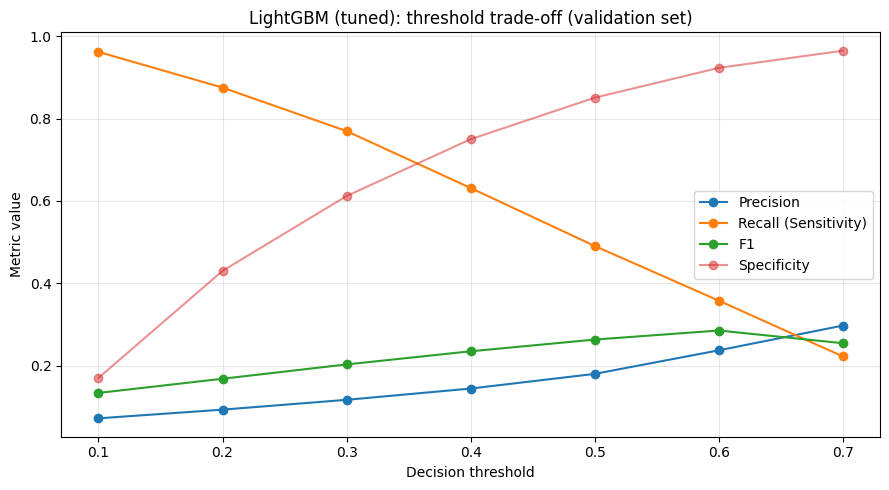

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
ax.plot(threshold_df["threshold"], threshold_df["recall_sensitivity"], marker="o", label="Recall (Sensitivity)")
ax.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
ax.plot(threshold_df["threshold"], threshold_df["specificity"], marker="o", label="Specificity", alpha=0.5)
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Metric value")
ax.set_title("LightGBM (tuned): threshold trade-off (validation set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "16_threshold_tradeoff.png", dpi=150)
plt.show()


## 3. False positives / false negatives at each threshold

**Why show raw counts, not just rates?** In an early-warning system, the
absolute number of false alarms per N patients is what a clinical team
actually experiences day to day — a rate alone can obscure operational
impact.


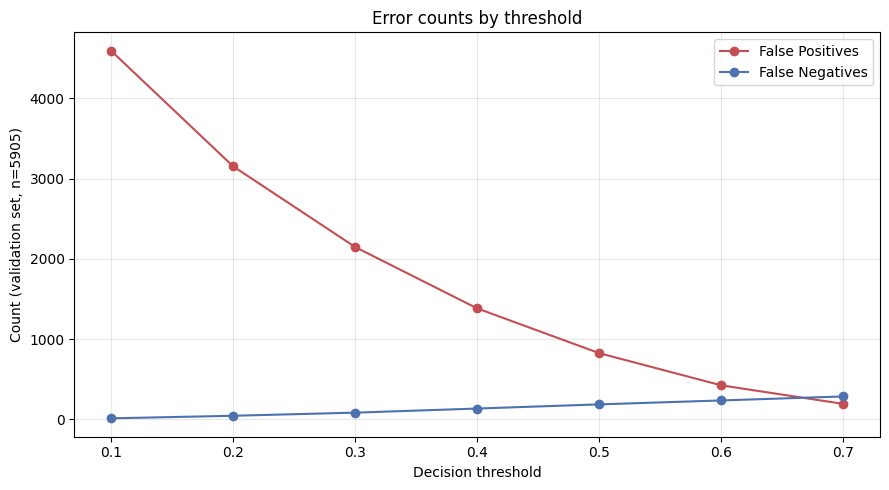

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df["threshold"], threshold_df["fp"], marker="o", label="False Positives", color="#C44E52")
ax.plot(threshold_df["threshold"], threshold_df["fn"], marker="o", label="False Negatives", color="#4C72B0")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Count (validation set, n=5905)")
ax.set_title("Error counts by threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "16_error_counts_by_threshold.png", dpi=150)
plt.show()


## 4. Select the final threshold

**Decision rule used here:** among thresholds achieving recall >= 0.50
(catching at least half of septic patients — a reasonable minimum for an
early-warning tool meant to reduce missed cases), pick the one with the
highest F1 (best precision/recall balance). This rule is stated explicitly
so the choice is reproducible and debatable, not arbitrary.

If NO threshold in the grid achieves recall >= 0.50, the closest one below
it is reported and flagged, rather than silently lowering the bar.


In [7]:
MIN_RECALL = 0.50
eligible = threshold_df[threshold_df["recall_sensitivity"] >= MIN_RECALL]

if len(eligible):
    chosen_row = eligible.loc[eligible["f1"].idxmax()]
    print(f"Thresholds meeting recall >= {MIN_RECALL}:")
    display(eligible[["threshold", "precision", "recall_sensitivity", "f1"]])
else:
    chosen_row = threshold_df.loc[threshold_df["recall_sensitivity"].idxmax()]
    print(f"WARNING: no threshold achieves recall >= {MIN_RECALL}. "
          f"Falling back to the threshold with the highest achievable recall.")

FINAL_THRESHOLD = float(chosen_row["threshold"])
print(f"\nSELECTED THRESHOLD: {FINAL_THRESHOLD}")
print(f"  Validation precision: {chosen_row['precision']:.4f}")
print(f"  Validation recall:    {chosen_row['recall_sensitivity']:.4f}")
print(f"  Validation F1:        {chosen_row['f1']:.4f}")


Thresholds meeting recall >= 0.5:


,threshold,precision,recall_sensitivity,f1
0,0.1,0.071717,0.962060,0.133484
1,0.2,0.092869,0.875339,0.167923
2,0.3,0.116728,0.769648,0.202712
3,0.4,0.144094,0.631436,0.234642



SELECTED THRESHOLD: 0.4
  Validation precision: 0.1441
  Validation recall:    0.6314
  Validation F1:        0.2346


## 5. ONLY NOW — evaluate on the test set, using the locked threshold

This is the single, final, honest test-set number for this model +
threshold combination. It is computed exactly once, after every decision
(model choice, hyperparameters, threshold) was made using training/
validation data only.


In [8]:
test_prob = model.predict_proba(X_test)[:, 1]
test_metrics_final = ev.compute_metrics(y_test, test_prob, threshold=FINAL_THRESHOLD)
ev.print_metrics(test_metrics_final, model_name=f"LightGBM (tuned), FINAL (test, threshold={FINAL_THRESHOLD})")

ev.save_model_results("LightGBM_tuned_FINAL_TEST", test_metrics_final)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- LightGBM (tuned), FINAL (test, threshold=0.4) (threshold=0.4) ---
  ROC-AUC:            0.7559
  PR-AUC:             0.2456
  Precision:          0.1480
  Recall (Sensitivity): 0.6108
  Specificity:        0.7650
  F1:                 0.2383
  Brier score:        0.1246
  Confusion matrix:   TN=4235 FP=1301 FN=144 TP=226


2026-09-15 08:14:59,605 | INFO | src.evaluate | Saved/updated results for 'LightGBM_tuned_FINAL_TEST' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv
INFO:src.evaluate:Saved/updated results for 'LightGBM_tuned_FINAL_TEST' in /content/drive/MyDrive/Early-Sepsis-Detection/reports/tables/model_comparison.csv


## 6. Save the threshold decision for Phase 23's model_metadata.json

In [9]:
threshold_decision = {
    "model": "LightGBM_tuned",
    "selected_threshold": FINAL_THRESHOLD,
    "selection_rule": f"max F1 among thresholds with validation recall >= {MIN_RECALL}",
    "validation_metrics_at_threshold": {k: v for k, v in chosen_row.to_dict().items()},
    "test_metrics_at_threshold": test_metrics_final,
}
import json
with open(config.TABLES_DIR / "16_threshold_decision.json", "w") as f:
    json.dump(threshold_decision, f, indent=2, default=str)

threshold_df.to_csv(config.TABLES_DIR / "16_threshold_grid_results.csv", index=False)
print("Saved threshold decision and full grid results.")


Saved threshold decision and full grid results.


---
### What to send back to Claude after running this notebook

- Section 1's full threshold grid table
- Section 4's selected threshold and its validation metrics
- Section 5's final test-set metrics at that threshold

With that, **Phase 18 is complete**, and we move to **Phase 19 (Probability
Calibration)** — addressing the systematic overconfidence seen in Phase 17's
calibration curves via Platt scaling or isotonic regression, evaluated
against this same locked threshold.
